In [6]:
import os
print(os.listdir())

['.config', 'adult.csv', 'sample_data']


In [7]:
import pandas as pd

df = pd.read_csv("adult.csv", engine="python", skipinitialspace=True, on_bad_lines="skip")

print(df.head())
print(df.shape)

   age workclass  fnlwgt     education  education.num marital.status  \
0   90         ?   77053       HS-grad              9        Widowed   
1   82   Private  132870       HS-grad              9        Widowed   
2   66         ?  186061  Some-college             10        Widowed   
3   54   Private  140359       7th-8th              4       Divorced   
4   41   Private  264663  Some-college             10      Separated   

          occupation   relationship   race     sex  capital.gain  \
0                  ?  Not-in-family  White  Female             0   
1    Exec-managerial  Not-in-family  White  Female             0   
2                  ?      Unmarried  Black  Female             0   
3  Machine-op-inspct      Unmarried  White  Female             0   
4     Prof-specialty      Own-child  White  Female             0   

   capital.loss  hours.per.week native.country income  
0          4356              40  United-States  <=50K  
1          4356              18  United-States

In [8]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv("adult.csv", engine="python", skipinitialspace=True, on_bad_lines="skip")

df.head()

,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
0,90,?,77053,HS-grad,9,Widowed,?,Not-in-family,White,Female,0,4356,40,United-States,<=50K
1,82,Private,132870,HS-grad,9,Widowed,Exec-managerial,Not-in-family,White,Female,0,4356,18,United-States,<=50K
2,66,?,186061,Some-college,10,Widowed,?,Unmarried,Black,Female,0,4356,40,United-States,<=50K
3,54,Private,140359,7th-8th,4,Divorced,Machine-op-inspct,Unmarried,White,Female,0,3900,40,United-States,<=50K
4,41,Private,264663,Some-college,10,Separated,Prof-specialty,Own-child,White,Female,0,3900,40,United-States,<=50K


In [9]:
df = df.replace("?", np.nan)
df.isnull().sum()

,0
age,0
workclass,1360
fnlwgt,0
education,0
education.num,0
marital.status,0
occupation,1364
relationship,0
race,0
sex,0


In [10]:
for col in df.columns:
    if df[col].dtype == "object":
        df[col] = df[col].fillna(df[col].mode()[0])
    else:
        df[col] = df[col].fillna(df[col].median())

df.isnull().sum()

,0
age,0
workclass,0
fnlwgt,0
education,0
education.num,0
marital.status,0
occupation,0
relationship,0
race,0
sex,0


In [11]:
print("Before:", df.duplicated().sum())

df = df.drop_duplicates()

print("After:", df.duplicated().sum())

Before: 8354
After: 0


In [12]:
print(df.dtypes)

df["age"] = pd.to_numeric(df["age"], errors="coerce")
df["workclass"] = df["workclass"].astype("category")

print(df.memory_usage(deep=True).sum())

age                int64
workclass         object
fnlwgt             int64
education         object
education.num      int64
marital.status    object
occupation        object
relationship      object
race              object
sex               object
capital.gain       int64
capital.loss       int64
hours.per.week     int64
native.country    object
income            object
dtype: object
8637761


In [13]:
skew = df.select_dtypes(include="number").skew()
print(skew)

most_skewed = skew.abs().idxmax()
print("Most skewed:", most_skewed)

age               0.538780
fnlwgt            1.332386
education.num    -0.294118
capital.gain      8.492371
capital.loss      3.055741
hours.per.week    0.211577
dtype: float64
Most skewed: capital.gain


In [14]:
col = "age"

Q1 = df[col].quantile(0.25)
Q3 = df[col].quantile(0.75)
IQR = Q3 - Q1

low = Q1 - 1.5 * IQR
high = Q3 + 1.5 * IQR

print(len(df[(df[col] < low) | (df[col] > high)]))

76


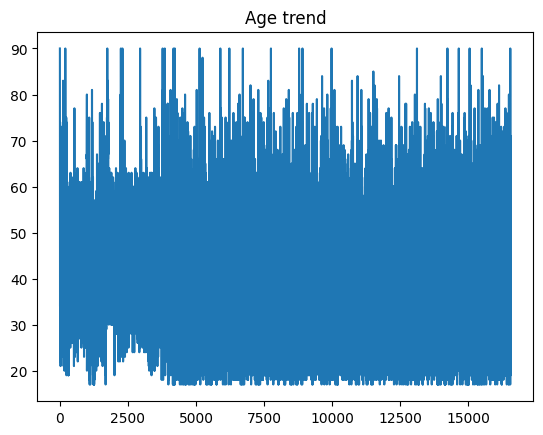

In [15]:
plt.plot(df["age"])
plt.title("Age trend")
plt.show()

/tmp/ipykernel_8673/2948254247.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("workclass")["age"].mean().plot(kind="bar")


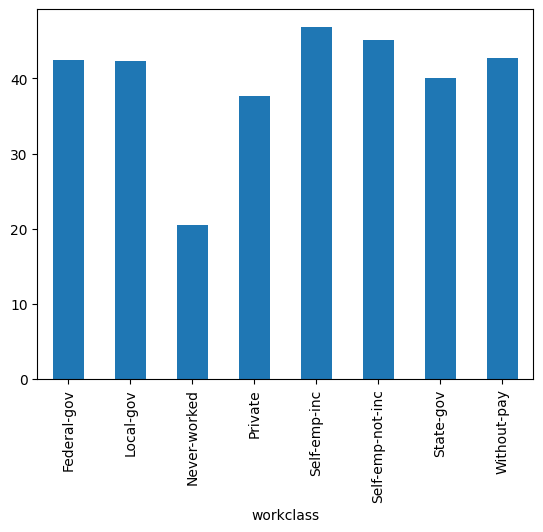

In [16]:
df.groupby("workclass")["age"].mean().plot(kind="bar")
plt.show()

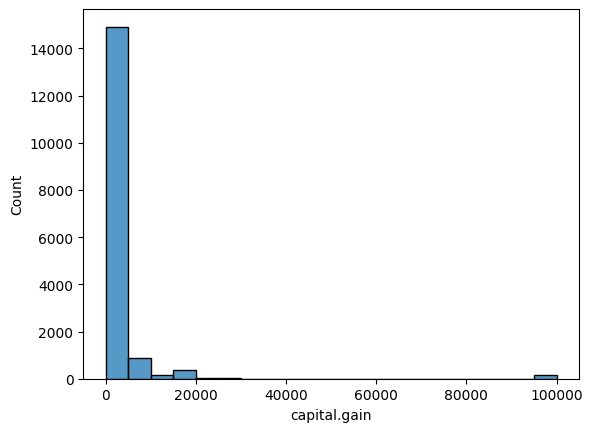

In [17]:
sns.histplot(df[most_skewed], bins=20)
plt.show()

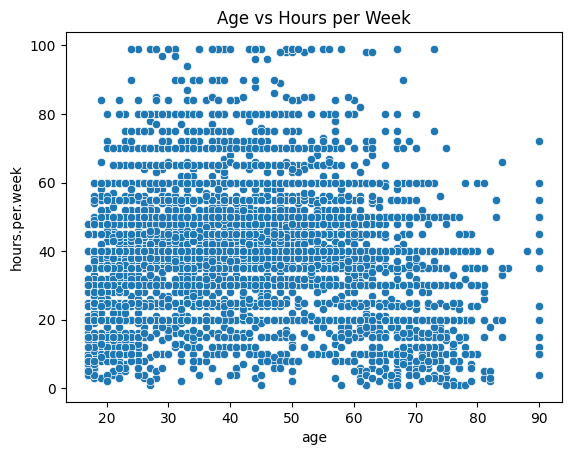

In [24]:
import seaborn as sns
import matplotlib.pyplot as plt

temp = df[["age", "hours.per.week"]].dropna()

sns.scatterplot(x="age", y="hours.per.week", data=temp)

plt.title("Age vs Hours per Week")
plt.show()

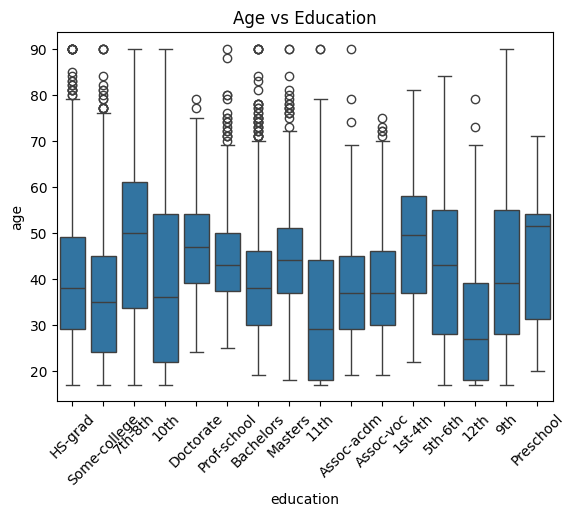

In [25]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(x="education", y="age", data=df)
plt.xticks(rotation=45)
plt.title("Age vs Education")
plt.show()

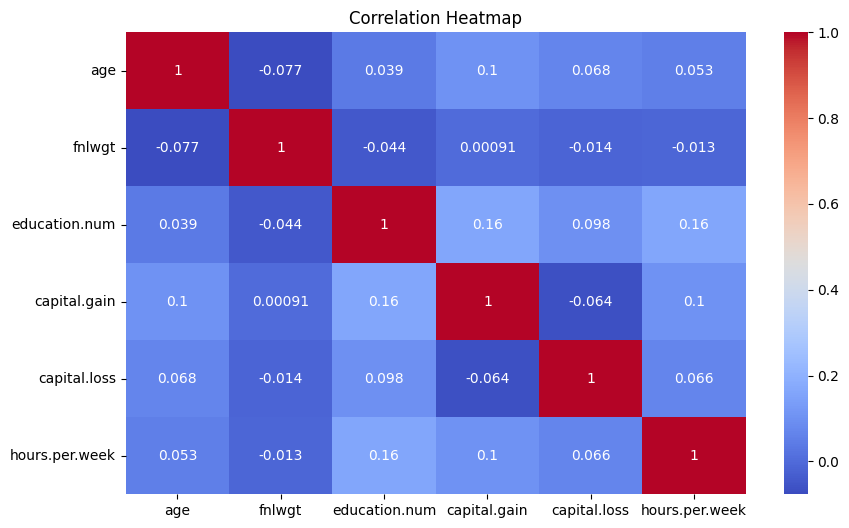

In [26]:
corr = df.select_dtypes(include="number").corr()

plt.figure(figsize=(10,6))
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

In [27]:
df.to_csv("cleaned_data.csv", index=False)
print("File saved successfully")

File saved successfully


In [28]:
df.head()
df.info()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
Index: 16567 entries, 0 to 16571
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype   
---  ------          --------------  -----   
 0   age             16567 non-null  int64   
 1   workclass       16567 non-null  category
 2   fnlwgt          16567 non-null  int64   
 3   education       16567 non-null  object  
 4   education.num   16567 non-null  int64   
 5   marital.status  16567 non-null  object  
 6   occupation      16567 non-null  object  
 7   relationship    16567 non-null  object  
 8   race            16567 non-null  object  
 9   sex             16567 non-null  object  
 10  capital.gain    16567 non-null  int64   
 11  capital.loss    16567 non-null  int64   
 12  hours.per.week  16567 non-null  int64   
 13  native.country  16567 non-null  object  
 14  income          16567 non-null  object  
dtypes: category(1), int64(6), object(8)
memory usage: 1.9+ MB


,0
age,0
workclass,0
fnlwgt,0
education,0
education.num,0
marital.status,0
occupation,0
relationship,0
race,0
sex,0


In [29]:
df.to_csv("cleaned_data.csv", index=False)
print("Saved successfully")

Saved successfully


In [30]:
from google.colab import files
files.download("cleaned_data.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>